Q1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Task 1: Overall averages

df = pd.read_csv("hospital_data.csv")

means = df.groupby("Treatment")["Recovery"].mean()

er_t1 = means.loc[1]
er_t0 = means.loc[0]
diff = er_t1 - er_t0

print(f"E[R | T=1] = {er_t1:.4f}")
print(f"E[R | T=0] = {er_t0:.4f}")
print(f"Difference = {diff:.4f}")

if er_t1 > er_t0:
    print("The new treatment appears better overall.")
else:
    print("The old treatment appears better overall.")

E[R | T=1] = 0.7071
E[R | T=0] = 0.7722
Difference = -0.0652
The old treatment appears better overall.


In [2]:
# Task 2: Stratified by hospital

# Stratified means by hospital and treatment
means = df.groupby(["Hospital", "Treatment"])["Recovery"].mean().unstack()

# Extract values
er_t1_h0 = means.loc[0, 1]
er_t0_h0 = means.loc[0, 0]
er_t1_h1 = means.loc[1, 1]
er_t0_h1 = means.loc[1, 0]

diff_h0 = er_t1_h0 - er_t0_h0
diff_h1 = er_t1_h1 - er_t0_h1

print("Hospital 0")
print(f"E[R | T=1, H=0] = {er_t1_h0:.4f}")
print(f"E[R | T=0, H=0] = {er_t0_h0:.4f}")
print(f"Difference = {diff_h0:.4f}\n")

print("Hospital 1")
print(f"E[R | T=1, H=1] = {er_t1_h1:.4f}")
print(f"E[R | T=0, H=1] = {er_t0_h1:.4f}")
print(f"Difference = {diff_h1:.4f}")

Hospital 0
E[R | T=1, H=0] = 0.8486
E[R | T=0, H=0] = 0.8041
Difference = 0.0446

Hospital 1
E[R | T=1, H=1] = 0.6508
E[R | T=0, H=1] = 0.5702
Difference = 0.0806


In [3]:
# Task 3: ACE via backdoor adjustment on H

# Conditional means E[R | T=t, H=h]
means = df.groupby(["Hospital", "Treatment"])["Recovery"].mean().unstack()

# Empirical distribution of H
p_h = df["Hospital"].value_counts(normalize=True).sort_index()

# Adjustment formula
er_do_1 = means.loc[0, 1] * p_h.loc[0] + means.loc[1, 1] * p_h.loc[1]
er_do_0 = means.loc[0, 0] * p_h.loc[0] + means.loc[1, 0] * p_h.loc[1]
ace = er_do_1 - er_do_0

print(f"P(H=0) = {p_h.loc[0]:.4f}")
print(f"P(H=1) = {p_h.loc[1]:.4f}\n")

print(f"E[R | do(T=1)] = {er_do_1:.4f}")
print(f"E[R | do(T=0)] = {er_do_0:.4f}")
print(f"ACE = {ace:.4f}")

P(H=0) = 0.6108
P(H=1) = 0.3892

E[R | do(T=1)] = 0.7716
E[R | do(T=0)] = 0.7130
ACE = 0.0586


Q2 (3)

In [2]:
# 1. Simulate one dataset from the SEM

def simulate_sem(n=150, seed=None):
    rng = np.random.default_rng(seed) #Set Seed

# Generate Variable F and S from uniform distributions
    F = rng.uniform(0.0, 0.45, n)
    S = rng.uniform(0.0, 0.45, n)

# Generate independent noise~ M, P, X and Y
    eps_M = rng.uniform(-0.18, 0.18, n)
    eps_P = rng.uniform(-0.18, 0.18, n)
    eps_X = rng.uniform(-0.35, 0.35, n)
    eps_Y = rng.uniform(-0.25, 0.25, n)

# Compute M and P based on their parents in the DAG.
    M = 0.8 * F + eps_M
    P = 0.7 * F + 0.7 * S + eps_P

#  Implements the indicator function X, retuns (1/0)
    X = (0.8 * P + 0.8 * M + eps_X > 0.32).astype(int)

#   Outcome equation from the SEM.
    Y = 2 * X + 1.2 * P + 1.2 * M + 0.8 * S + eps_Y

# Collect all variables into a table for further analysis
    df = pd.DataFrame({
        "F": F,
        "S": S,
        "M": M,
        "P": P,
        "X": X,
        "Y": Y
    })
    return df

In [3]:
# 2. Discretize variables into bins of width 0.1

def discretize_col(df, cols, width=0.1):
    df = df.copy()

    for col in cols:
        # floor(x / width) gives the bin index
        df[col + "_bin"] = np.floor(df[col] / width).astype(int)

    return df

In [4]:
# 3. Estimate ATE using discrete adjustment formula

def estimate_ate_adjustment(df, z_cols, width=0.1):
    """
    Estimate:
        sum_z [ E[Y|X=1,Z=z] - E[Y|X=0,Z=z] ] * P_hat(Z=z)

    We only keep strata z where both X=1 and X=0 are observed,
    because otherwise the conditional mean difference is not estimable
    from that dataset.
    """
    df_disc = discretize_col(df, z_cols, width=width)
    z_bin_cols = [col + "_bin" for col in z_cols]

    # empirical P_hat(Z=z)
    strata_prob = (
        df_disc
        .groupby(z_bin_cols)
        .size()
        .reset_index(name="count")
    )
    strata_prob["p_hat"] = strata_prob["count"] / len(df_disc)

    # conditional means E[Y | X=x, Z=z]
    mean_y = (
        df_disc
        .groupby(z_bin_cols + ["X"])["Y"]
        .mean()
        .reset_index()
    )

    # pivot to get columns for X=0 and X=1
    mean_y_pivot = mean_y.pivot_table(
        index=z_bin_cols,
        columns="X",
        values="Y"
    ).reset_index()

    # rename columns safely
    mean_y_pivot = mean_y_pivot.rename(columns={0: "EY_X0", 1: "EY_X1"})

    # merge with empirical strata probs
    merged = pd.merge(strata_prob, mean_y_pivot, on=z_bin_cols, how="left")

    # keep only strata where both treatment groups appear
    merged = merged.dropna(subset=["EY_X0", "EY_X1"]).copy()

    merged["p_hat"] = merged["p_hat"] / merged["p_hat"].sum()
    merged["diff"] = merged["EY_X1"] - merged["EY_X0"]
    ate_hat = (merged["diff"] * merged["p_hat"]).sum()

    return ate_hat

In [5]:
# 4. Repeat 100 times

def run_simulation(n_rep=100, n=150, width=0.1, base_seed=123):
    ate_z1 = []
    ate_z2 = []

    for r in range(n_rep):
        df = simulate_sem(n=n, seed=base_seed + r)

        # Z1 = {P, M}
        ate1 = estimate_ate_adjustment(df, z_cols=["P", "M"], width=width)

        # Z2 = {P, M, F, S}
        ate2 = estimate_ate_adjustment(df, z_cols=["P", "M", "F", "S"], width=width)

        ate_z1.append(ate1)
        ate_z2.append(ate2)

    return np.array(ate_z1), np.array(ate_z2)


In [6]:
# 5. Run and summarize

ate_z1, ate_z2 = run_simulation(n_rep=100, n=150, width=0.1, base_seed=123)

print("Z1 = {P, M}")
print(f"Mean ATE estimate: {np.nanmean(ate_z1):.4f}")
print(f"Std  ATE estimate: {np.nanstd(ate_z1, ddof=1):.4f}")
print()

print("Z2 = {P, M, F, S}")
print(f"Mean ATE estimate: {np.nanmean(ate_z2):.4f}")
print(f"Std  ATE estimate: {np.nanstd(ate_z2, ddof=1):.4f}")

Z1 = {P, M}
Mean ATE estimate: 2.0148
Std  ATE estimate: 0.0460

Z2 = {P, M, F, S}
Mean ATE estimate: 2.0130
Std  ATE estimate: 0.0674


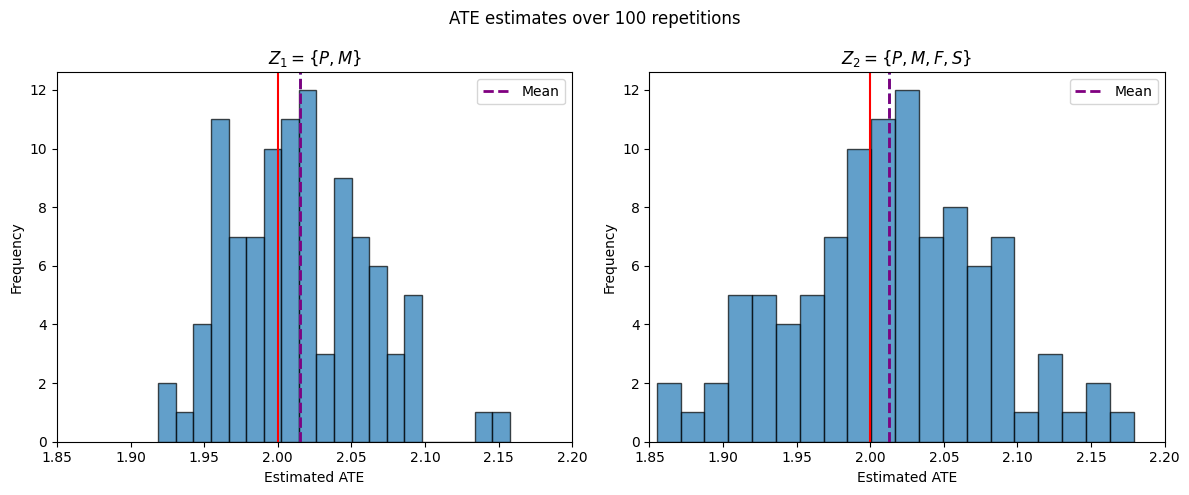

In [7]:
# 6. Plot on the same figure

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Z1 ----
axes[0].hist(ate_z1, bins=20, alpha=0.7, edgecolor="black")
axes[0].axvline(np.nanmean(ate_z1), linestyle="--", linewidth=2)
axes[0].set_title(r"$Z_1=\{P,M\}$")
axes[0].set_xlabel("Estimated ATE")
axes[0].set_ylabel("Frequency")

# ---- Z2 ----
axes[1].hist(ate_z2, bins=20, alpha=0.7, edgecolor="black")
axes[1].axvline(np.nanmean(ate_z2), linestyle="--", linewidth=2)
axes[1].set_title(r"$Z_2=\{P,M,F,S\}$")
axes[1].set_xlabel("Estimated ATE")
axes[1].set_ylabel("Frequency")

axes[0].set_xlim(1.85, 2.2)
axes[1].set_xlim(1.85, 2.2)

axes[0].axvline(np.nanmean(ate_z1), color = "purple", linestyle="--", linewidth=2, label="Mean")
axes[0].legend()

axes[1].axvline(np.nanmean(ate_z2), color = "purple", linestyle="--", linewidth=2, label="Mean")
axes[1].legend()

axes[0].axvline(2, color="red", linestyle="-", label="True ATE")
axes[1].axvline(2, color="red", linestyle="-", label="True ATE")

plt.suptitle("ATE estimates over 100 repetitions")
plt.tight_layout()
plt.show()